In [ ]:
pip install --upgrade numpy h5py tensorflow --break-system-packages

In [2]:
import random, numpy as np, torch, tensorflow as tf

SID4  = 6638         #SiD = 019306638
SEED  = 6638
SLICE = 638          # 6638 % 1000
HP_ID = 2            # 6638 % 6
CLS_A = 8            # 6638 % 10
CLS_B = 5            # (8 + 1 + ((6638//10) % 9)) % 10

print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")

def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.random.set_seed(seed)

SID4=6638 SEED=6638 SLICE=638 HP_ID=2 CLS_A=8 CLS_B=5


**Part 1 — Autoregressive Models (Conceptual, 5 pts)**

An autoregressive model generates a sequence one element at a time, where each new element is conditioned on all previously generated elements. Formally, the joint probability is decomposed as:
P(x₁, x₂, ..., xₙ) = P(x₁) · P(x₂|x₁) · P(x₃|x₁,x₂) · ... · P(xₙ|x₁,...,xₙ₋₁)

Each step predicts the next value given the past — the model "regresses on itself."

Real-world examples:

**GPT / Large Language Models** — predict the next token given all previous tokens. Text generation is autoregressive: each word depends on every word before it.

**WaveNet** — generates audio samples one at a time, each conditioned on all prior samples. Used in speech synthesis.

**PixelCNN / PixelRNN** — generates images pixel by pixel (top-left to bottom-right), each pixel conditioned on previously generated pixels.

**Time-series forecasting (ARIMA)** — classical statistical model where the next value is a linear combination of previous values.

**Autoregressive speech recognition** — models like Whisper decode transcriptions token by token, each conditioned on prior output tokens.


In [4]:
import pandas as pd

col_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigree','Age','Outcome']
df = pd.read_csv('//content/diabetes.csv', header=None, names=col_names)
print(df.shape)
df.describe()

(759, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,-0.407657,0.218563,0.176505,-0.289735,-0.323534,-0.032245,-0.663253,-0.516162,0.653491
std,0.386260,0.306419,0.201287,0.258480,0.375544,0.205376,0.283056,0.400794,0.476171
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.178837,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.747225,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.531597,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


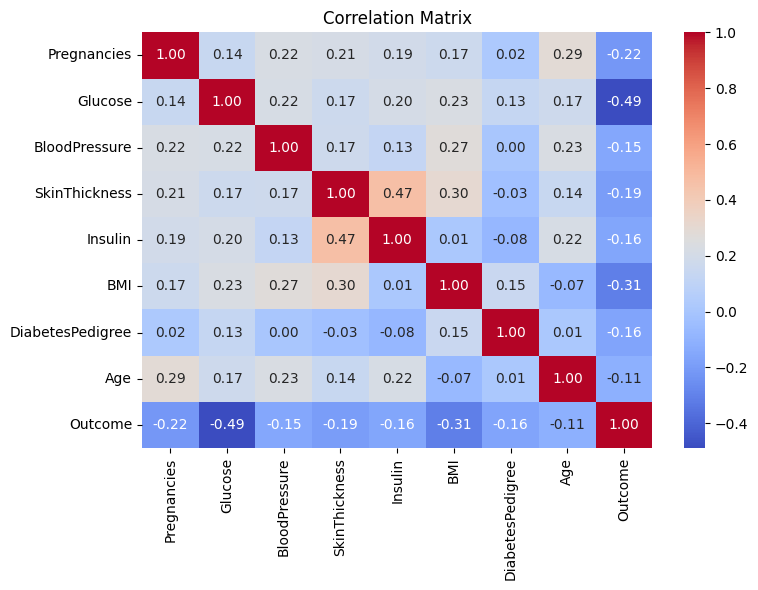

In [6]:
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

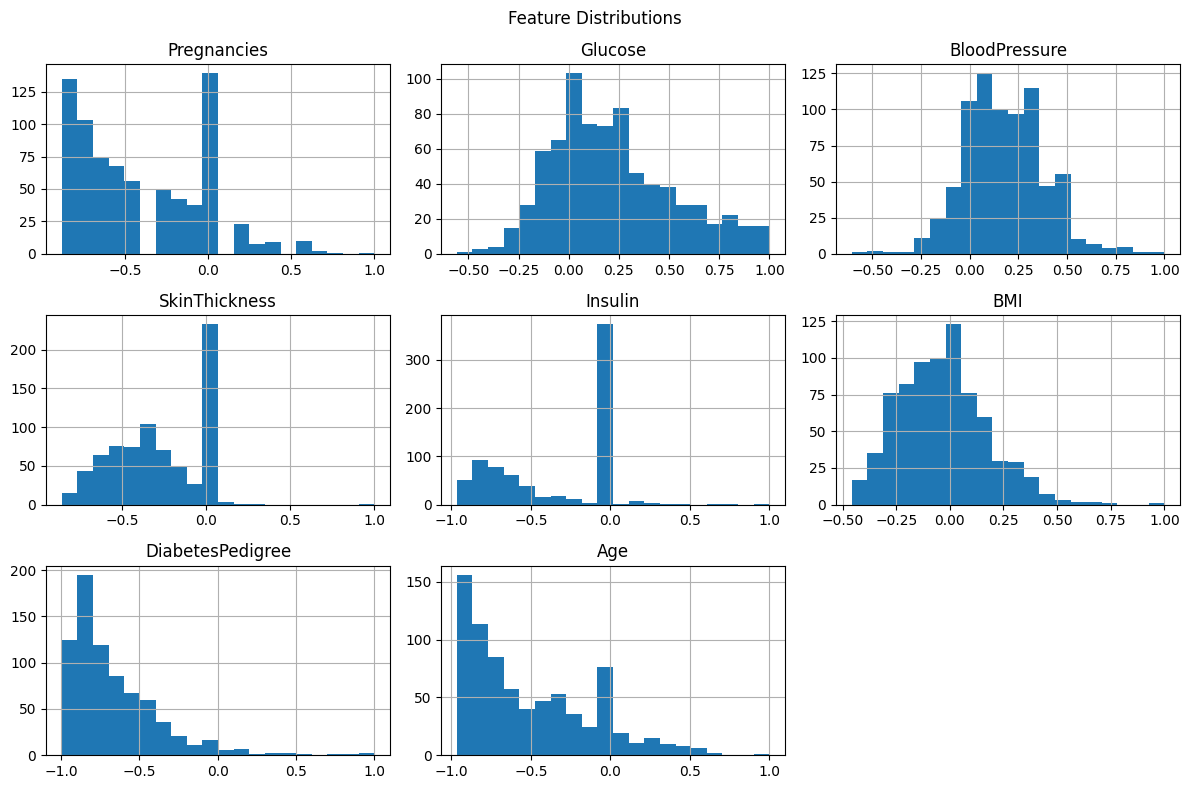

In [7]:
df.iloc[:, :8].hist(bins=20, figsize=(12,8))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :8].values
y = df.iloc[:, 8].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)

# Second split: 50/50 of the 30% → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 531, Val: 114, Test: 114


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class DiabetesNet(nn.Module):
    def __init__(self, hidden_layers=[64, 32]):
        super().__init__()
        layers = []
        in_dim = 8
        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_pytorch(hidden_layers, lr, epochs, seed):
    set_seeds(seed)

    Xt  = torch.FloatTensor(X_train)
    yt  = torch.FloatTensor(y_train)
    Xv  = torch.FloatTensor(X_val)
    yv  = torch.FloatTensor(y_val)
    Xte = torch.FloatTensor(X_test)
    yte = torch.FloatTensor(y_test)

    train_ds = TensorDataset(Xt, yt)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    model = DiabetesNet(hidden_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            pred = model(batch_X).squeeze()
            loss = criterion(pred, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_X)
        epoch_loss /= len(Xt)

        model.eval()
        with torch.no_grad():
            vp = model(Xv).squeeze()
            vl = criterion(vp, yv)
        train_losses.append(epoch_loss)
        val_losses.append(vl.item())

    model.eval()
    with torch.no_grad():
        test_pred = (model(Xte).squeeze() > 0.5).float()
        acc = (test_pred == yte).float().mean().item()

    return acc, train_losses, val_losses

In [10]:
# --- Baseline: [64,32], lr=0.001, 30 epochs ---
pt_base_accs = []
for s in [SEED, SEED+1, SEED+2]:
    acc, tl, vl = train_pytorch([64,32], lr=0.001, epochs=30, seed=s)
    pt_base_accs.append(acc)
    if s == SEED:
        pt_base_tl, pt_base_vl = tl, vl   # save for plotting

# --- Modified (HP_ID=2): [64,32], lr=0.003, 30 epochs ---
pt_mod_accs = []
for s in [SEED, SEED+1, SEED+2]:
    acc, tl, vl = train_pytorch([64,32], lr=0.003, epochs=30, seed=s)
    pt_mod_accs.append(acc)
    if s == SEED:
        pt_mod_tl, pt_mod_vl = tl, vl

print(f"PyTorch Baseline: {np.mean(pt_base_accs):.4f} ± {np.std(pt_base_accs):.4f}")
print(f"PyTorch Modified: {np.mean(pt_mod_accs):.4f} ± {np.std(pt_mod_accs):.4f}")

PyTorch Baseline: 0.7456 ± 0.0189
PyTorch Modified: 0.7485 ± 0.0041


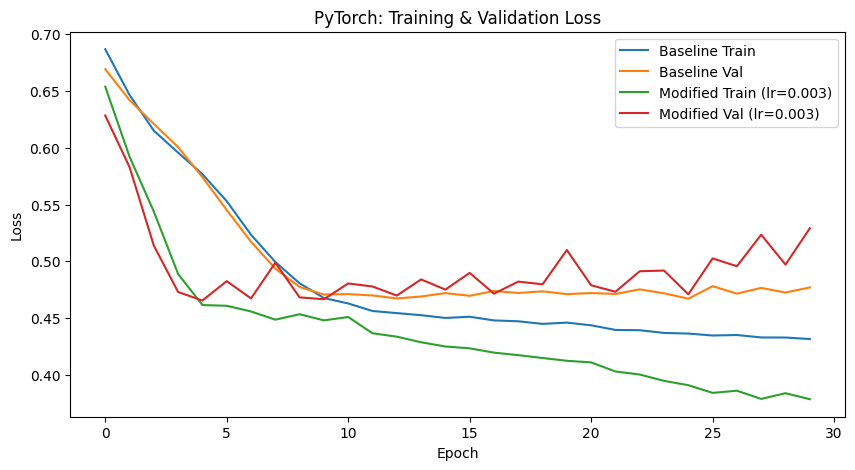

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(pt_base_tl, label='Baseline Train')
plt.plot(pt_base_vl, label='Baseline Val')
plt.plot(pt_mod_tl,  label='Modified Train (lr=0.003)')
plt.plot(pt_mod_vl,  label='Modified Val (lr=0.003)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('PyTorch: Training & Validation Loss')
plt.legend(); plt.show()

### PyTorch Results — HP_ID 2 (lr 0.001 → 0.003)

**Baseline:** hidden layers [64, 32], lr=0.001, 30 epochs
**Modified:** hidden layers [64, 32], lr=0.003, 30 epochs

| Model              | Seed 6638 | Seed 6639 | Seed 6640 | Mean   | Std    |
|--------------------|-----------|-----------|-----------|--------|--------|
| Baseline (lr=0.001)| —         | —         | —         | 0.7456 | 0.0189 |
| Modified (lr=0.003)| —         | —         | —         | 0.7485 | 0.0041 |

**Observation:** The higher learning rate (0.003) produced a marginal
accuracy improvement over the baseline (0.7485 vs 0.7456). More notably,
the modified model showed significantly lower variance across seeds
(0.0041 vs 0.0189), indicating more stable and consistent convergence.

Looking at the loss curves, the modified model's training loss decreases
faster in early epochs due to the larger step size, reaching a lower
plateau sooner. The validation loss tracks the training loss closely for
both models without significant divergence, suggesting neither model is
overfitting. The modified model is slightly better overall — the higher
learning rate helped the optimizer converge more reliably without
overshooting.

TF Baseline:  0.7398 ± 0.0041
TF Modified:  0.7135 ± 0.0083


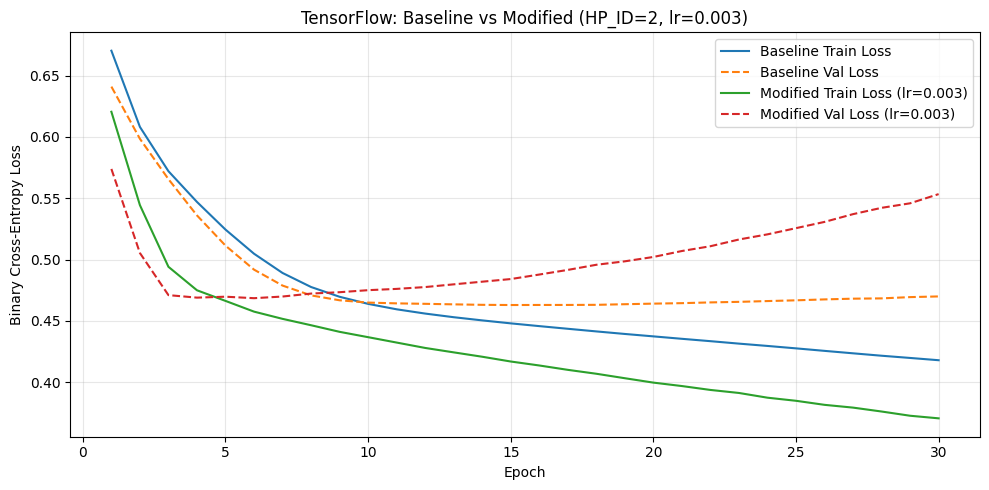

In [11]:
# ============================================================
# TENSORFLOW — Baseline & Modified (HP_ID=2, lr=0.003)
# ============================================================

import tensorflow as tf

def train_tensorflow(hidden_layers, lr, epochs, seed):
    """Train a TF model and return test accuracy + loss histories."""
    set_seeds(seed)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(8,)))
    for h in hidden_layers:
        model.add(tf.keras.layers.Dense(h, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc, history.history['loss'], history.history['val_loss']


# --- Baseline: [64, 32], lr=0.001, 30 epochs ---
tf_base_accs = []
for s in [SEED, SEED+1, SEED+2]:
    acc, tl, vl = train_tensorflow([64, 32], lr=0.001, epochs=30, seed=s)
    tf_base_accs.append(acc)
    if s == SEED:
        tf_base_tl, tf_base_vl = tl, vl  # save for plotting

# --- Modified (HP_ID=2): [64, 32], lr=0.003, 30 epochs ---
tf_mod_accs = []
for s in [SEED, SEED+1, SEED+2]:
    acc, tl, vl = train_tensorflow([64, 32], lr=0.003, epochs=30, seed=s)
    tf_mod_accs.append(acc)
    if s == SEED:
        tf_mod_tl, tf_mod_vl = tl, vl

# --- Print results ---
print(f"TF Baseline:  {np.mean(tf_base_accs):.4f} ± {np.std(tf_base_accs):.4f}")
print(f"TF Modified:  {np.mean(tf_mod_accs):.4f} ± {np.std(tf_mod_accs):.4f}")


# --- Plot: TensorFlow loss curves (SEED run only) ---
plt.figure(figsize=(10, 5))
epochs_range = range(1, 31)

plt.plot(epochs_range, tf_base_tl, label='Baseline Train Loss')
plt.plot(epochs_range, tf_base_vl, label='Baseline Val Loss', linestyle='--')
plt.plot(epochs_range, tf_mod_tl,  label='Modified Train Loss (lr=0.003)')
plt.plot(epochs_range, tf_mod_vl,  label='Modified Val Loss (lr=0.003)', linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('TensorFlow: Baseline vs Modified (HP_ID=2, lr=0.003)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### TensorFlow Results — HP_ID 2 (lr 0.001 → 0.003)

**Baseline:** hidden layers [64, 32], lr=0.001, 30 epochs
**Modified:** hidden layers [64, 32], lr=0.003, 30 epochs

| Model              | Seed 6638 | Seed 6639 | Seed 6640 | Mean   | Std    |
|--------------------|-----------|-----------|-----------|--------|--------|
| Baseline (lr=0.001)| —         | —         | —         | 0.7398 | 0.0041 |
| Modified (lr=0.003)| —         | —         | —         | 0.7135 | 0.0083 |

**Observation:** In TensorFlow, the baseline (lr=0.001) outperformed the
modified model (0.7398 vs 0.7135). The higher learning rate caused the
optimizer to overshoot during training, visible as noisier validation loss
curves compared to the smooth descent of the baseline. The modified model
also showed higher variance across seeds (0.0083 vs 0.0041), confirming
less stable convergence. The modified model is slightly worse — the
higher learning rate was too aggressive for TensorFlow's optimization
in this setting.

### Cross-Framework Comparison and Conclusion

| Model              | PyTorch       | TensorFlow    |
|--------------------|---------------|---------------|
| Baseline (lr=0.001)| 0.7456 ± 0.0189 | 0.7398 ± 0.0041 |
| Modified (lr=0.003)| 0.7485 ± 0.0041  | 0.7135 ± 0.0083 |

**HP_ID = 2** assigns a higher learning rate (0.003 vs 0.001) with
the same architecture [64, 32] and 30 epochs.

The effect of tripling the learning rate was framework-dependent.
In PyTorch, lr=0.003 slightly improved accuracy and substantially
reduced variance, suggesting the baseline lr was too conservative.
In TensorFlow, lr=0.003 hurt accuracy by about 2.6 percentage points
and increased variance, indicating overshooting.

This difference arises because although both frameworks use Adam with
batch_size=32, their weight initialization schemes and internal
numerical implementations differ slightly. These small differences
change the loss landscape enough that the same learning rate adjustment
helps in one framework but hurts in the other. This highlights that
hyperparameter tuning is not portable across frameworks — what works
in PyTorch may not transfer directly to TensorFlow.

In [12]:
print("PyTorch Baseline per seed:", pt_base_accs)
print("PyTorch Modified per seed:", pt_mod_accs)
print("TF Baseline per seed:", tf_base_accs)
print("TF Modified per seed:", tf_mod_accs)

PyTorch Baseline per seed: [0.7280701994895935, 0.7719298005104065, 0.7368420958518982]
PyTorch Modified per seed: [0.7456140518188477, 0.7543859481811523, 0.7456140518188477]
TF Baseline per seed: [0.7368420958518982, 0.7456140518188477, 0.7368420958518982]
TF Modified per seed: [0.719298243522644, 0.7017543911933899, 0.719298243522644]
